<a href="https://colab.research.google.com/github/NazHub1993/Deep-Learning/blob/main/Customer_Churn_Prediction(ANN)%5BArtificial_Neural_Network%5D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [37]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [38]:
df=pd.read_csv('customer_churn.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [39]:
df.drop('customerID',axis='columns',inplace=True)

In [40]:
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


In [41]:
df.TotalCharges.values

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

In [42]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')

In [43]:
df['TotalCharges'].dtype

dtype('float64')

In [44]:
df['TotalCharges'].isnull().sum()

np.int64(11)

In [45]:
df.shape

(7043, 20)

In [46]:
df.dropna(subset=['TotalCharges'],inplace=True)

In [47]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [48]:
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object
OnlineBackup,object


#Time to visualize the tenure

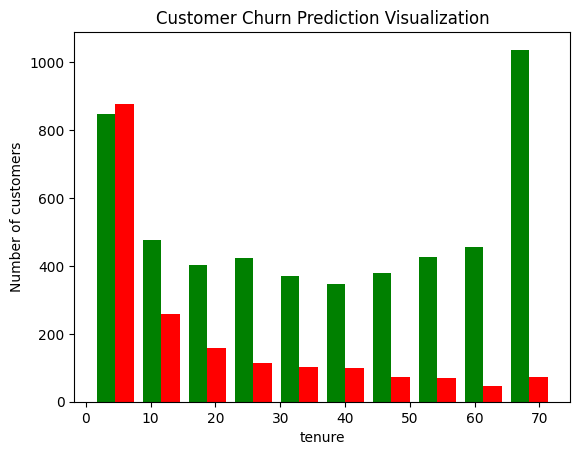

In [49]:
tenure_churn_no=df[df.Churn=="No"].tenure
tenure_churn_yes=df[df.Churn=="Yes"].tenure

plt.xlabel("tenure")
plt.ylabel("Number of customers")
plt.title("Customer Churn Prediction Visualization")

plt.hist([tenure_churn_no,tenure_churn_yes],color=['green','red'],label=['churn==no','churn==yes'])
plt.show()

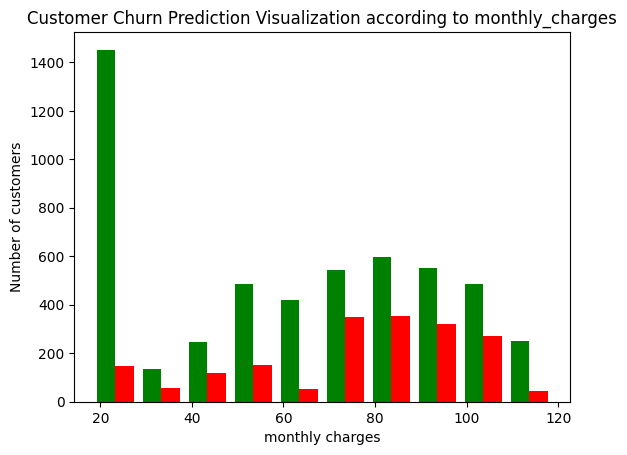

In [50]:
mc_churn_no=df[df.Churn=="No"].MonthlyCharges
mc_churn_yes=df[df.Churn=="Yes"].MonthlyCharges

plt.xlabel("monthly charges")
plt.ylabel("Number of customers")
plt.title("Customer Churn Prediction Visualization according to monthly_charges")

plt.hist([mc_churn_no,mc_churn_yes],color=['green','red'],label=['churn_no','churn_yes'])
plt.show()


#How to know which columns are of object type?

In [51]:
def print_unique_vals(df):
  for column in df:
    if df[column].dtype=='object':
      print(f'{column}: unique_values: {df[column].unique()}')

In [52]:
print_unique_vals(df)


gender: unique_values: ['Female' 'Male']
Partner: unique_values: ['Yes' 'No']
Dependents: unique_values: ['No' 'Yes']
PhoneService: unique_values: ['No' 'Yes']
MultipleLines: unique_values: ['No phone service' 'No' 'Yes']
InternetService: unique_values: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: unique_values: ['No' 'Yes' 'No internet service']
OnlineBackup: unique_values: ['Yes' 'No' 'No internet service']
DeviceProtection: unique_values: ['No' 'Yes' 'No internet service']
TechSupport: unique_values: ['No' 'Yes' 'No internet service']
StreamingTV: unique_values: ['No' 'Yes' 'No internet service']
StreamingMovies: unique_values: ['No' 'Yes' 'No internet service']
Contract: unique_values: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: unique_values: ['Yes' 'No']
PaymentMethod: unique_values: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: unique_values: ['No' 'Yes']


In [53]:
df.replace('No internet service','No',inplace=True)
df.replace('No phone service','No',inplace=True)

In [54]:
print_unique_vals(df)

gender: unique_values: ['Female' 'Male']
Partner: unique_values: ['Yes' 'No']
Dependents: unique_values: ['No' 'Yes']
PhoneService: unique_values: ['No' 'Yes']
MultipleLines: unique_values: ['No' 'Yes']
InternetService: unique_values: ['DSL' 'Fiber optic' 'No']
OnlineSecurity: unique_values: ['No' 'Yes']
OnlineBackup: unique_values: ['Yes' 'No']
DeviceProtection: unique_values: ['No' 'Yes']
TechSupport: unique_values: ['No' 'Yes']
StreamingTV: unique_values: ['No' 'Yes']
StreamingMovies: unique_values: ['No' 'Yes']
Contract: unique_values: ['Month-to-month' 'One year' 'Two year']
PaperlessBilling: unique_values: ['Yes' 'No']
PaymentMethod: unique_values: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']
Churn: unique_values: ['No' 'Yes']


#Turning the YES NO columns in 1 or 0

In [55]:
yes_no_columns = ['Partner','Dependents','PhoneService','MultipleLines','OnlineSecurity','OnlineBackup',
                  'DeviceProtection','TechSupport','StreamingTV','StreamingMovies','PaperlessBilling','Churn']
for col in yes_no_columns:
  df[col].replace({'Yes':1,'No':0},inplace=True)


/tmp/ipykernel_4963/414633514.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].replace({'Yes':1,'No':0},inplace=True)
/tmp/ipykernel_4963/414633514.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col].replace({'Yes':1,'No':0},inplace=True)


In [56]:
print_unique_vals(df)


gender: unique_values: ['Female' 'Male']
InternetService: unique_values: ['DSL' 'Fiber optic' 'No']
Contract: unique_values: ['Month-to-month' 'One year' 'Two year']
PaymentMethod: unique_values: ['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']


In [57]:
df.dtypes

,0
gender,object
SeniorCitizen,int64
Partner,int64
Dependents,int64
tenure,int64
PhoneService,int64
MultipleLines,int64
InternetService,object
OnlineSecurity,int64
OnlineBackup,int64


In [58]:
df['gender'].replace({'Male':0,'Female':1},inplace=True)

/tmp/ipykernel_4963/1735084570.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['gender'].replace({'Male':0,'Female':1},inplace=True)
/tmp/ipykernel_4963/1735084570.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['gender'].replace({'Male':0,'Female':1},inplace=True)


#Now One Hot Encoding for the object type columns

In [59]:
df=pd.get_dummies(data=df,columns=['InternetService','Contract','PaymentMethod'])

In [60]:
for column in df:
  print(f"{column}:: {df[column].unique()}")

gender:: [1 0]
SeniorCitizen:: [0 1]
Partner:: [1 0]
Dependents:: [0 1]
tenure:: [ 1 34  2 45  8 22 10 28 62 13 16 58 49 25 69 52 71 21 12 30 47 72 17 27
  5 46 11 70 63 43 15 60 18 66  9  3 31 50 64 56  7 42 35 48 29 65 38 68
 32 55 37 36 41  6  4 33 67 23 57 61 14 20 53 40 59 24 44 19 54 51 26 39]
PhoneService:: [0 1]
MultipleLines:: [0 1]
OnlineSecurity:: [0 1]
OnlineBackup:: [1 0]
DeviceProtection:: [0 1]
TechSupport:: [0 1]
StreamingTV:: [0 1]
StreamingMovies:: [0 1]
PaperlessBilling:: [1 0]
MonthlyCharges:: [29.85 56.95 53.85 ... 63.1  44.2  78.7 ]
TotalCharges:: [  29.85 1889.5   108.15 ...  346.45  306.6  6844.5 ]
Churn:: [0 1]
InternetService_DSL:: [ True False]
InternetService_Fiber optic:: [False  True]
InternetService_No:: [False  True]
Contract_Month-to-month:: [ True False]
Contract_One year:: [False  True]
Contract_Two year:: [False  True]
PaymentMethod_Bank transfer (automatic):: [False  True]
PaymentMethod_Credit card (automatic):: [False  True]
PaymentMethod_Electroni

#Scale the numeric cols

In [61]:
cols_to_scale = ['tenure','MonthlyCharges','TotalCharges']

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

#Now my data frame is ready.

In [62]:
X=df.drop('Churn',axis='columns')
Y=df['Churn']

In [63]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(X,Y,test_size=0.2,random_state=42)

In [64]:
x_train.shape

(5625, 26)

#Build ANN in tensorflow

In [70]:
model=keras.Sequential(
    [
        keras.layers.Dense(20,input_shape=(26,),activation='relu'),
        keras.layers.Dense(15,activation='relu'),
        keras.layers.Dense(1,activation='sigmoid')
    ]
)

model.compile(
    optimizer='SGD',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(x_train,y_train,epochs=50)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7333 - loss: 0.5742
Epoch 2/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7342 - loss: 0.5197
Epoch 3/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7369 - loss: 0.4874
Epoch 4/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7525 - loss: 0.4660
Epoch 5/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7749 - loss: 0.4531
Epoch 6/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7788 - loss: 0.4449
Epoch 7/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7831 - loss: 0.4398
Epoch 8/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7854 - loss: 0.4363
Epoch 9/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7867 - loss: 0.4335
Epoch 10/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7895 - loss: 0.4314
Epoch 11/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7920 - loss: 0.4296
Epoch 12/50
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy

In [71]:
model.evaluate(x_test,y_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7839 - loss: 0.4382


[0.43815138936042786, 0.7839374542236328]

In [72]:
yp = model.predict(x_test)
y_pred = []
for element in yp:
    if element > 0.5:
        y_pred.append(1)
    else:
        y_pred.append(0)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [73]:
y_test[:5]

,Churn
2481,0
6784,0
6125,1
3052,0
4099,0


In [74]:
y_pred[:5]

[0, 0, 1, 0, 0]

In [75]:
from sklearn.metrics import confusion_matrix,classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1033
           1       0.61      0.51      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.71      1407
weighted avg       0.77      0.78      0.78      1407



Text(95.72222222222221, 0.5, 'Truth')

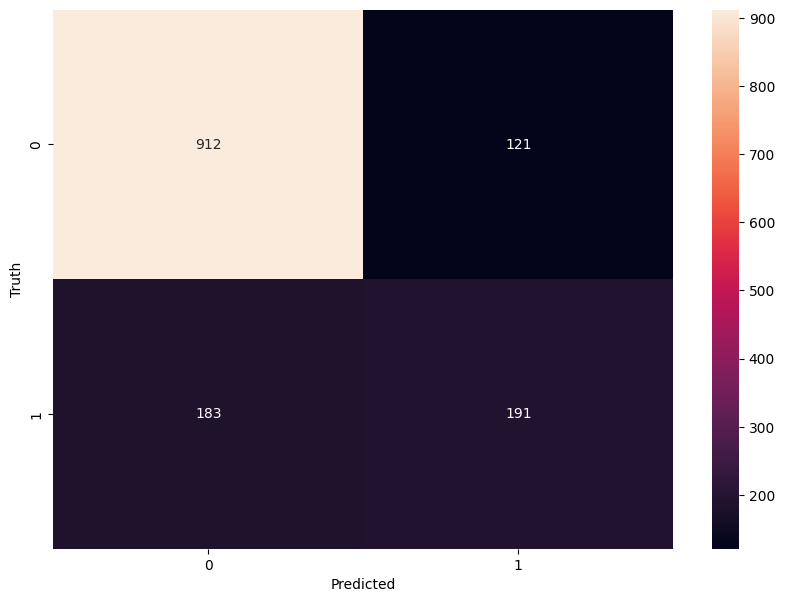

In [76]:
import seaborn as sn
cm = tf.math.confusion_matrix(labels=y_test,predictions=y_pred)

plt.figure(figsize = (10,7))
sn.heatmap(cm, annot=True, fmt='d')
plt.xlabel('Predicted')
plt.ylabel('Truth')